# Confidence Intervals

In this section we will be exploring confidence intervals. We will start by simulating many confidence intervals from the standard normal distribution and plotting them alongside the true mean. Confidence intervals are calculated using the following formula:

$$
\bar{x} \pm t \times (\frac{s}{\sqrt n})
$$

As we can observe from this formula, confidence intervals are dependent on the sample size (n), standard deviation, expectation, and confidence level. Feel free to play around with these values in the code below.

```{note}
In practice we only use a single confidence interval, but we can visualize the meaning of a confidence interval by simulating many at once.
```

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

C:\Users\Stella\AppData\Local\Temp\ipykernel_23632\640873109.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


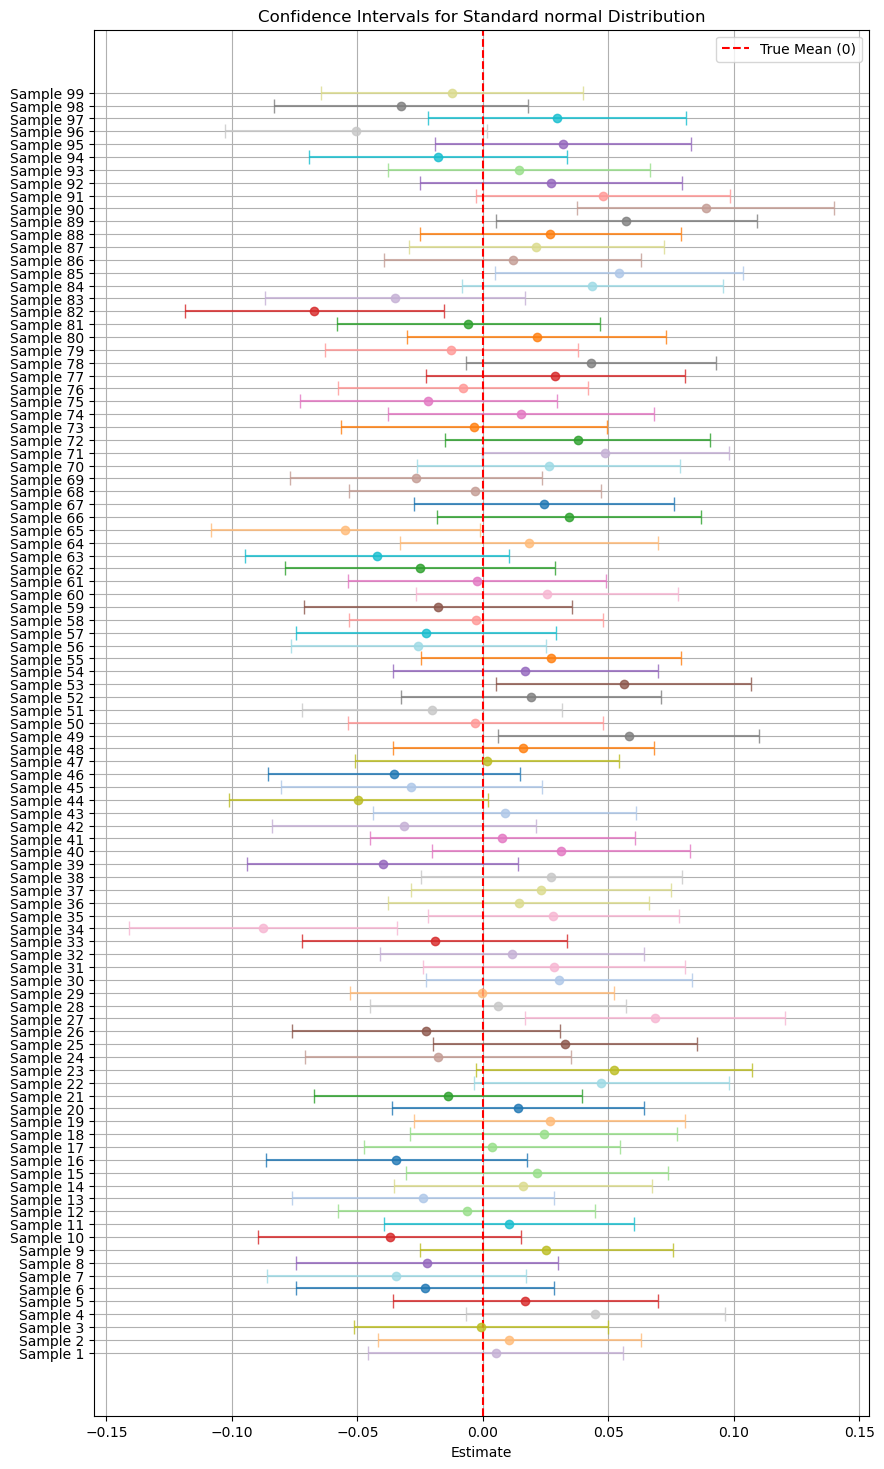

In [ ]:
x_values = np.arange(1, 100)
point_estimates = []
ci_lower_bounds = []
ci_upper_bounds = []
n = 1000
standard_deviation = 1
expectation = 0
confidence_level = 0.95

for x in x_values:
    sample = np.random.normal(loc=expectation, scale=standard_deviation, size=n)

    point_estimate = np.mean(sample)
    standard_deviation = np.std(sample, ddof=1)
    t = stats.t.ppf(confidence_level, n - 1)
    margin_of_error = t * (standard_deviation / np.sqrt(n))
    ci_lower_bound = point_estimate - margin_of_error
    ci_upper_bound = point_estimate + margin_of_error
    point_estimates.append(point_estimate)
    ci_lower_bounds.append(ci_lower_bound)
    ci_upper_bounds.append(ci_upper_bound)

point_estimates = np.array(point_estimates)
ci_lower_bounds = np.array(ci_lower_bounds)
ci_upper_bounds = np.array(ci_upper_bounds)

lower_errors = point_estimates - ci_lower_bounds
upper_errors = ci_upper_bounds - point_estimates

bounds = np.array([lower_errors, upper_errors])

plt.figure(figsize=(10, 18))

# unique color for each interval
colors = plt.cm.tab20(np.linspace(0, 1, len(x_values)))
np.random.shuffle(colors)

for i, (x_val, point_est, lower_err, upper_err) in enumerate(
    zip(x_values, point_estimates, lower_errors, upper_errors)
):
    plt.errorbar(
        point_est,
        x_val,
        xerr=[[lower_err], [upper_err]],
        fmt="o",
        capsize=5,
        color=colors[i],
        alpha=0.8,
    )

# single color for all points
# plt.errorbar(point_estimates, x_values, xerr=bounds, fmt='o', capsize=5, label='Confidence Intervals')

# plot intervals
plt.xlabel("Estimate")
plt.title("Confidence Intervals for Standard normal Distribution")
plt.yticks(x_values, [f"Sample {i}" for i in x_values])
plt.legend()
plt.grid(True)
plt.axvline(x=0, color="r", linestyle="--", label="True Mean (0)")
plt.legend()
plt.tight_layout
plt.show()

As we can see from the simulated intervals, an $n\%$ confidence interval is an indicator that about $n\%$ of intervals would contain the true population mean. In this case, when we simulate 100 confidence intervals at $95\%$ confidence level, we expect about $5$ of the intervals would not contain the true population mean.

Let's explore the impact of sample size, standard deviation, expectation, and confidence level on our confidence intervals. 

In [51]:
def build_confidence_intervals(
    x_values, n, standard_deviation, expectation, confidence_level
):
    point_estimates = []
    ci_lower_bounds = []
    ci_upper_bounds = []

    for i, (x, n_i, sd, exp, cl) in enumerate(
        zip(x_values, n, standard_deviation, expectation, confidence_level)
    ):
        sample = np.random.normal(loc=exp, scale=sd, size=n_i)

        point_estimate = np.mean(sample)
        standard_deviation = np.std(sample, ddof=1)
        t = stats.t.ppf(cl, n_i - 1)
        margin_of_error = t * (sd / np.sqrt(n_i))
        ci_lower_bound = point_estimate - margin_of_error
        ci_upper_bound = point_estimate + margin_of_error
        point_estimates.append(point_estimate)
        ci_lower_bounds.append(ci_lower_bound)
        ci_upper_bounds.append(ci_upper_bound)

    point_estimates = np.array(point_estimates)
    ci_lower_bounds = np.array(ci_lower_bounds)
    ci_upper_bounds = np.array(ci_upper_bounds)

    lower_errors = point_estimates - ci_lower_bounds
    upper_errors = ci_upper_bounds - point_estimates

    return (np.array([lower_errors, upper_errors]), point_estimates)

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Stella\AppData\Local\Temp\ipykernel_23632\36135039.py:24: SyntaxWarning: invalid escape sequence '\s'
  plt.yticks(x_values, [f"Sample $\sigma$={i}" for i in standard_deviation])


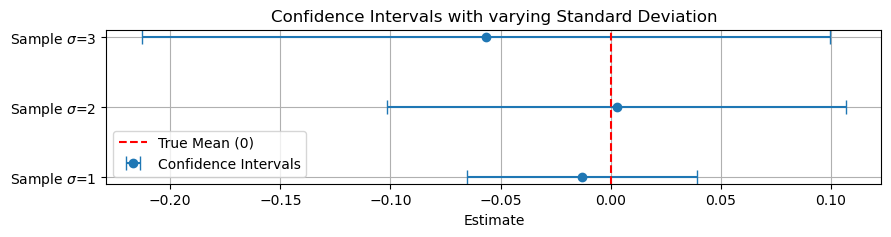

In [54]:
x_values = np.arange(1, 4)

n = [1000, 1000, 1000]
standard_deviation = [1, 2, 3]
expectation = [0, 0, 0]
confidence_level = [0.95, 0.95, 0.95]

bounds, point_estimates = build_confidence_intervals(
    x_values, n, standard_deviation, expectation, confidence_level
)

# plot intervals
plt.figure(figsize=(10, 2))
plt.errorbar(
    point_estimates,
    x_values,
    xerr=bounds,
    fmt="o",
    capsize=5,
    label="Confidence Intervals",
)
plt.xlabel("Estimate")
plt.title("Confidence Intervals with varying Standard Deviation")
plt.yticks(x_values, [f"Sample $\sigma$={i}" for i in standard_deviation])
plt.legend()
plt.grid(True)
plt.axvline(x=0, color="r", linestyle="--", label="True Mean (0)")
plt.legend()
plt.tight_layout
plt.show()

In [ ]:
n = [1000, 100, 10]
standard_deviation = [1, 1, 1]
expectation = [0, 0, 0]
confidence_level = [0.95, 0.95, 0.95]

bounds, point_estimates = build_confidence_intervals(
    x_values, n, standard_deviation, expectation, confidence_level
)

# plot intervals
plt.figure(figsize=(10, 2))
plt.errorbar(
    point_estimates,
    x_values,
    xerr=bounds,
    fmt="o",
    capsize=5,
    label="Confidence Intervals",
)
plt.xlabel("Estimate")
plt.title("Confidence Intervals with varying sample size")
plt.yticks(x_values, [f"Sample size={i}" for i in n])
plt.legend()
plt.grid(True)
plt.axvline(x=0, color="r", linestyle="--", label="True Mean (0)")
plt.legend()
plt.tight_layout
plt.show()

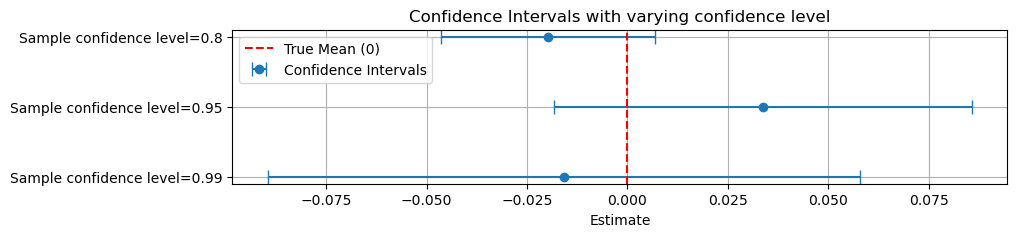

In [53]:
n = [1000, 1000, 1000]
standard_deviation = [1, 1, 1]
expectation = [0, 0, 0]
confidence_level = [0.99, 0.95, 0.8]

bounds, point_estimates = build_confidence_intervals(
    x_values, n, standard_deviation, expectation, confidence_level
)

# plot intervals
plt.figure(figsize=(10, 2))
plt.errorbar(
    point_estimates,
    x_values,
    xerr=bounds,
    fmt="o",
    capsize=5,
    label="Confidence Intervals",
)
plt.xlabel("Estimate")
plt.title("Confidence Intervals with varying confidence level")
plt.yticks(x_values, [f"Sample confidence level={i}" for i in confidence_level])
plt.legend()
plt.grid(True)
plt.axvline(x=0, color="r", linestyle="--", label="True Mean (0)")
plt.legend()
plt.tight_layout
plt.show()